# Importar librerías

In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import os

from datasets import load_dataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


In [11]:
# Scaler y modelo se crearán a partir del dataset cargado.
scaler = None
model_bilstm = None


# Cargar dataset

In [12]:
ds = load_dataset("mltrev23/gold-price")
df_nuevo = ds["train"].to_pandas()

print(f"Shape original: {df_nuevo.shape}")
print(df_nuevo.head)

Repo card metadata block was not found. Setting CardData to empty.


Shape original: (1718, 81)
<bound method NDFrame.head of             Date        Open        High         Low       Close   Adj Close  \
0     2011-12-15  154.740005  154.949997  151.710007  152.330002  152.330002   
1     2011-12-16  154.309998  155.369995  153.899994  155.229996  155.229996   
2     2011-12-19  155.479996  155.860001  154.360001  154.869995  154.869995   
3     2011-12-20  156.820007  157.429993  156.580002  156.979996  156.979996   
4     2011-12-21  156.979996  157.529999  156.130005  157.160004  157.160004   
...          ...         ...         ...         ...         ...         ...   
1713  2018-12-24  119.570000  120.139999  119.570000  120.019997  120.019997   
1714  2018-12-26  120.620003  121.000000  119.570000  119.660004  119.660004   
1715  2018-12-27  120.570000  120.900002  120.139999  120.570000  120.570000   
1716  2018-12-28  120.800003  121.080002  120.720001  121.059998  121.059998   
1717  2018-12-31  120.980003  121.260002  120.830002  121.25000

# Preprocesamiento de datos

In [13]:
# Usamos solo Close, igual que tu dataset original
df_nuevo = df_nuevo[["Date", "Close"]].copy()
df_nuevo["Date"] = pd.to_datetime(df_nuevo["Date"])
df_nuevo = df_nuevo.sort_values("Date").reset_index(drop=True)
df_nuevo = df_nuevo.dropna()

print(f"\nRango de fechas: {df_nuevo['Date'].min()} → {df_nuevo['Date'].max()}")
print(f"Total filas: {len(df_nuevo)}")


Rango de fechas: 2011-12-15 00:00:00 → 2018-12-31 00:00:00
Total filas: 1718


# Escalar

In [14]:
# Generamos un scaler propio a partir del dataset cargado
scaler = MinMaxScaler(feature_range=(0, 1))
precios = df_nuevo["Close"].values.reshape(-1, 1)
precios_scaled = scaler.fit_transform(precios)


# Separar train/test

In [15]:
TIME_STEPS = 30

def crear_secuencias(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

X_nuevo, y_nuevo = crear_secuencias(precios_scaled, TIME_STEPS)
print(f"\nX_nuevo: {X_nuevo.shape} | y_nuevo: {y_nuevo.shape}")

split = int(len(X_nuevo) * 0.85)
X_ft_train, X_ft_test = X_nuevo[:split], X_nuevo[split:]
y_ft_train, y_ft_test = y_nuevo[:split], y_nuevo[split:]

print(f"Train: {X_ft_train.shape} | Test: {X_ft_test.shape}")

model_bilstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(TIME_STEPS, 1)),
    Bidirectional(LSTM(32)),
    Dense(16, activation="relu"),
    Dense(1)
])

model_bilstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

callbacks_base = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

history_base = model_bilstm.fit(
    X_ft_train, y_ft_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks_base,
    verbose=1
)

y_pred_antes = model_bilstm.predict(X_ft_test)
y_pred_antes_inv = scaler.inverse_transform(y_pred_antes)
y_real_inv = scaler.inverse_transform(y_ft_test.reshape(-1, 1))

mae_antes = mean_absolute_error(y_real_inv, y_pred_antes_inv)
rmse_antes = np.sqrt(mean_squared_error(y_real_inv, y_pred_antes_inv))
r2_antes = r2_score(y_real_inv, y_pred_antes_inv)



X_nuevo: (1688, 30, 1) | y_nuevo: (1688, 1)
Train: (1434, 30, 1) | Test: (254, 30, 1)


c:\Users\pedre\OneDrive\Documentos\ProyectoFinal\venv_proyectoFinal\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 45s 277ms/step - loss: 0.0122 - mae: 0.0769 - val_loss: 0.0014 - val_mae: 0.0291
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 203ms/step - loss: 0.0030 - mae: 0.0420 - val_loss: 8.1719e-04 - val_mae: 0.0236
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - loss: 0.0022 - mae: 0.0364 - val_loss: 5.8221e-04 - val_mae: 0.0193
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - loss: 0.0016 - mae: 0.0305 - val_loss: 4.4733e-04 - val_mae: 0.0171
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - loss: 0.0013 - mae: 0.0286 - val_loss: 3.8580e-04 - val_mae: 0.0162
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - loss: 0.0012 - mae: 0.0269 - val_loss: 3.5040e-04 - val_mae: 0.0155
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - loss: 0.0011 - mae: 0.0263 - val_loss: 3.1641e-04 - val_mae: 0.0148
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - loss: 0.0011 - mae: 0.0257 - val_loss: 3.0521e-04 - val_mae: 0.0144
Epoch 9/20
41/41 ━━━━━━━━

# Fine-Tunning

In [16]:
model_bilstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=["mae"]
)

callbacks_ft = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

history_ft = model_bilstm.fit(
    X_ft_train, y_ft_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks_ft,
    verbose=1
)

y_pred_despues = model_bilstm.predict(X_ft_test)
y_pred_despues_inv = scaler.inverse_transform(y_pred_despues)

mae_despues  = mean_absolute_error(y_real_inv, y_pred_despues_inv)
rmse_despues = np.sqrt(mean_squared_error(y_real_inv, y_pred_despues_inv))
r2_despues   = r2_score(y_real_inv, y_pred_despues_inv)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 52s 305ms/step - loss: 6.1243e-04 - mae: 0.0187 - val_loss: 1.8644e-04 - val_mae: 0.0112
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 171ms/step - loss: 5.7698e-04 - mae: 0.0180 - val_loss: 1.7935e-04 - val_mae: 0.0111
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - loss: 5.7966e-04 - mae: 0.0181 - val_loss: 1.7726e-04 - val_mae: 0.0110
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - loss: 5.7401e-04 - mae: 0.0180 - val_loss: 1.7494e-04 - val_mae: 0.0109
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 170ms/step - loss: 5.7011e-04 - mae: 0.0179 - val_loss: 1.7269e-04 - val_mae: 0.0108
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 170ms/step - loss: 5.6611e-04 - mae: 0.0178 - val_loss: 1.7060e-04 - val_mae: 0.0108
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 185ms/step - loss: 5.6196e-04 - mae: 0.0177 - val_loss: 1.6839e-04 - val_mae: 0.0107
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 174ms/step - loss: 5.5713e-04 - mae: 0.0176 - val_loss: 1.6650e-04 - val_m

In [17]:
tabla = pd.DataFrame([
    {"Etapa": "Antes del fine-tuning",  "MAE": round(mae_antes, 4),   "RMSE": round(rmse_antes, 4),   "R²": round(r2_antes, 4)},
    {"Etapa": "Después del fine-tuning","MAE": round(mae_despues, 4), "RMSE": round(rmse_despues, 4), "R²": round(r2_despues, 4)},
])
print("\n── Comparativa ──")
print(tabla.to_string(index=False))


── Comparativa ──
                  Etapa    MAE   RMSE     R²
  Antes del fine-tuning 0.7538 0.9652 0.9646
Después del fine-tuning 0.6837 0.8875 0.9701


# Gráfica

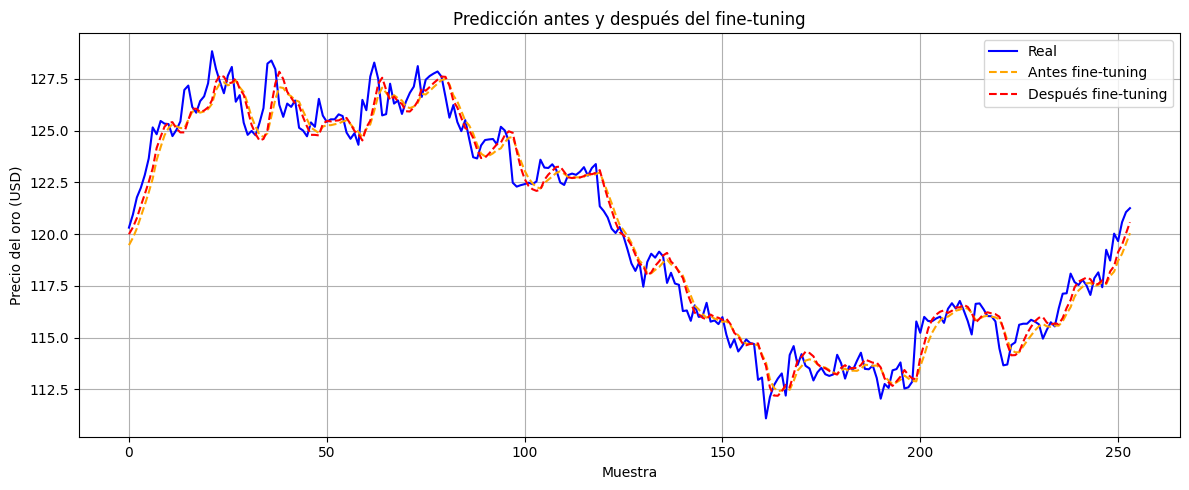

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(y_real_inv,         label="Real",             color="blue")
plt.plot(y_pred_antes_inv,   label="Antes fine-tuning",color="orange", linestyle="--")
plt.plot(y_pred_despues_inv, label="Después fine-tuning", color="red", linestyle="--")
plt.title("Predicción antes y después del fine-tuning")
plt.xlabel("Muestra")
plt.ylabel("Precio del oro (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Como podemos observar, tras aplicar fine-tuning al modelo, se produce una mejora en todas las métricas de evaluación. El error medio absoluto (MAE) disminuye de 0,75 a 0,68, el error cuadrático medio (RMSE) pasa de 0,97 a 0,89 y el coeficiente de determinación (R²) aumenta de 0,9646 a 0,9701. Aunque la mejora no es muy grande, esto se debe a que el modelo ya ofrecía buenos resultados antes del ajuste. Gracias al uso de una tasa de aprendizaje baja (0,0001), el modelo puede adaptarse mejor a los nuevos datos sin perder el conocimiento adquirido durante el entrenamiento inicial, consiguiendo así predicciones ligeramente más precisas del precio del oro.